In [64]:
# =========================================================
# 1) Exploración inicial de las variables
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset desde GitHub
url = "https://github.com/Kalbam/Datos/raw/main/base_imputacion_mixta_1000.csv"
df = pd.read_csv(url)

# Vista general de los primeros registros
print("=== Primeras filas ===")
display(df.head())

# Información de estructura
print("\n=== Información general ===")
print(df.info())

# Resumen estadístico de las variables numéricas
print("\n=== Descripción estadística (numéricas) ===")
display(df.describe())

# Resumen de variables categóricas
print("\n=== Valores únicos por variable categórica ===")
for col in df.select_dtypes(include="object").columns:
    print(f"{col}: {df[col].nunique()} categorías -> {df[col].unique()[:10]}")


=== Primeras filas ===


,fecha,sexo,ciudad,nivel_educativo,segmento,estado_civil,edad,altura_cm,ingresos,gasto_mensual,puntuacion_credito,demanda
0,2024-01-01,F,Medellín,NaN,B,Unión libre,19.0,161.821754,3574.753806,1832.731832,640.465372,119.202995
1,2024-01-02,F,Barranquilla,NaN,B,NaN,52.0,167.819566,3163.626815,NaN,533.108430,124.457874
2,2024-01-03,M,Bogotá,Secundaria,B,Soltero/a,38.0,165.756219,2765.672259,1219.535074,491.016910,NaN
3,2024-01-04,F,Bogotá,NaN,B,Casado/a,57.0,160.642670,4320.397345,1908.324816,NaN,129.426792
4,2024-01-05,M,Cali,Técnico,B,Soltero/a,67.0,151.402909,NaN,1887.385697,610.213994,133.916319



=== Información general ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fecha               1000 non-null   object 
 1   sexo                980 non-null    object 
 2   ciudad              950 non-null    object 
 3   nivel_educativo     900 non-null    object 
 4   segmento            800 non-null    object 
 5   estado_civil        650 non-null    object 
 6   edad                970 non-null    float64
 7   altura_cm           920 non-null    float64
 8   ingresos            880 non-null    float64
 9   gasto_mensual       750 non-null    float64
 10  puntuacion_credito  500 non-null    float64
 11  demanda             850 non-null    float64
dtypes: float64(6), object(6)
memory usage: 93.9+ KB
None

=== Descripción estadística (numéricas) ===


,edad,altura_cm,ingresos,gasto_mensual,puntuacion_credito,demanda
count,970.000000,920.000000,880.000000,750.000000,500.000000,850.000000
mean,42.861856,167.760096,3681.294745,1687.810749,599.077500,160.305759
std,14.621382,9.275530,1079.326096,582.070174,79.828186,25.357794
min,18.000000,140.000000,487.662547,100.000000,373.657944,99.875828
25%,30.000000,161.488768,2999.416229,1309.239768,544.467843,139.505538
50%,43.000000,167.714614,3669.620507,1676.193764,599.692595,160.721251
75%,55.000000,173.999069,4375.093656,2063.260990,653.345068,181.100754
max,69.000000,195.766921,7016.246936,3532.593603,823.539585,222.093047



=== Valores únicos por variable categórica ===
fecha: 1000 categorías -> ['2024-01-01' '2024-01-02' '2024-01-03' '2024-01-04' '2024-01-05'
 '2024-01-06' '2024-01-07' '2024-01-08' '2024-01-09' '2024-01-10']
sexo: 2 categorías -> ['F' 'M' nan]
ciudad: 5 categorías -> ['Medellín' 'Barranquilla' 'Bogotá' 'Cali' nan 'Cartagena']
nivel_educativo: 4 categorías -> [nan 'Secundaria' 'Técnico' 'Universitario' 'Posgrado']
segmento: 3 categorías -> ['B' nan 'C' 'A']
estado_civil: 4 categorías -> ['Unión libre' nan 'Soltero/a' 'Casado/a' 'Divorciado/a']


In [65]:
from scipy.stats import kstest
import numpy as np

titulos = df.select_dtypes(include=[np.number]).columns.tolist() 


for col in titulos:
    datos = df[col].dropna()
    stat_col, p_col = kstest(datos, "norm", args=(datos.mean(), datos.std(ddof=1)))
    print(f"{col} -> KS = {stat_col:.4f}, p = {p_col:.4f}")



edad -> KS = 0.0728, p = 0.0001
altura_cm -> KS = 0.0225, p = 0.7320
ingresos -> KS = 0.0192, p = 0.8950
gasto_mensual -> KS = 0.0183, p = 0.9589
puntuacion_credito -> KS = 0.0175, p = 0.9974
demanda -> KS = 0.0503, p = 0.0260


In [66]:
pd.DataFrame(df.columns, columns=["Nombres de variables"])


,Nombres de variables
0,fecha
1,sexo
2,ciudad
3,nivel_educativo
4,segmento
5,estado_civil
6,edad
7,altura_cm
8,ingresos
9,gasto_mensual


=== Resumen de valores nulos ===
                    Nulos  Porcentaje (%)
puntuacion_credito    500            50.0
estado_civil          350            35.0
gasto_mensual         250            25.0
segmento              200            20.0
demanda               150            15.0
ingresos              120            12.0
nivel_educativo       100            10.0
altura_cm              80             8.0
ciudad                 50             5.0
edad                   30             3.0
sexo                   20             2.0
fecha                   0             0.0


C:\Users\migue\AppData\Local\Temp\ipykernel_6372\1428512382.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=missing_summary_sorted.index,


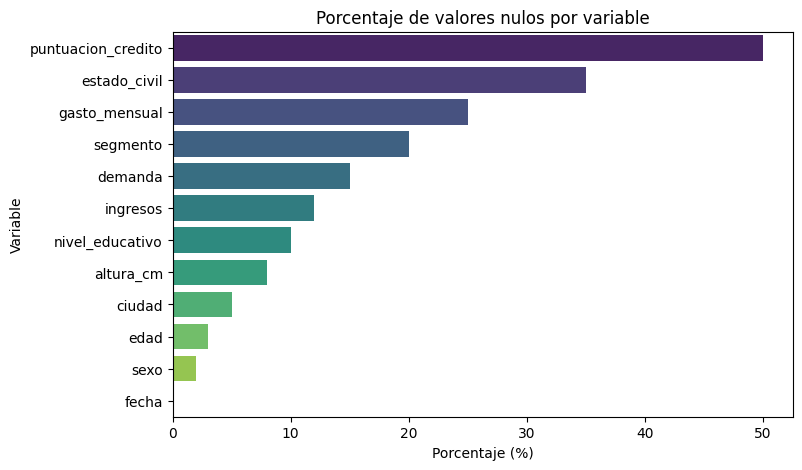

In [67]:
total = len(df)
null_counts = df.isna().sum()
null_percent = (null_counts / total) * 100


missing_summary = pd.DataFrame({
    "Nulos": null_counts,
    "Porcentaje (%)": null_percent.round(2)
})

missing_summary_sorted = missing_summary.sort_values("Porcentaje (%)", ascending=False)

print("=== Resumen de valores nulos ===")
print(missing_summary_sorted)


plt.figure(figsize=(8,5))
sns.barplot(y=missing_summary_sorted.index, 
            x=missing_summary_sorted["Porcentaje (%)"], 
            palette="viridis")
plt.title("Porcentaje de valores nulos por variable")
plt.xlabel("Porcentaje (%)")
plt.ylabel("Variable")
plt.show()


In [68]:
from sklearn.impute import SimpleImputer

# Copia del df original
df_imputado = df.copy()

# --- Imputación numéricas ---
# edad (no normal) -> mediana
imp_median = SimpleImputer(strategy="median")
df_imputado[["edad"]] = imp_median.fit_transform(df_imputado[["edad"]])

# altura_cm (normal) -> media
imp_mean = SimpleImputer(strategy="mean")
df_imputado[["altura_cm"]] = imp_mean.fit_transform(df_imputado[["altura_cm"]])

# --- Imputación categóricas ---
imp_moda = SimpleImputer(strategy="most_frequent")
df_imputado[["ciudad"]] = imp_moda.fit_transform(df_imputado[["ciudad"]])
df_imputado[["sexo"]]   = imp_moda.fit_transform(df_imputado[["sexo"]])

# --- Verificación ---
print("\nNulos originales:\n", df.isna().sum())
print("Valores nulos después de imputar:")
print(df_imputado[["edad","altura_cm","ciudad","sexo"]].isna().sum())

print("\nPrimeras filas (imputadas):")
print(df_imputado.head(4))



Nulos originales:
 fecha                   0
sexo                   20
ciudad                 50
nivel_educativo       100
segmento              200
estado_civil          350
edad                   30
altura_cm              80
ingresos              120
gasto_mensual         250
puntuacion_credito    500
demanda               150
dtype: int64
Valores nulos después de imputar:
edad         0
altura_cm    0
ciudad       0
sexo         0
dtype: int64

Primeras filas (imputadas):
        fecha sexo        ciudad nivel_educativo segmento estado_civil  edad  \
0  2024-01-01    F      Medellín             NaN        B  Unión libre  19.0   
1  2024-01-02    F  Barranquilla             NaN        B          NaN  52.0   
2  2024-01-03    M        Bogotá      Secundaria        B    Soltero/a  38.0   
3  2024-01-04    F        Bogotá             NaN        B     Casado/a  57.0   

    altura_cm     ingresos  gasto_mensual  puntuacion_credito     demanda  
0  161.821754  3574.753806    1832.731832 

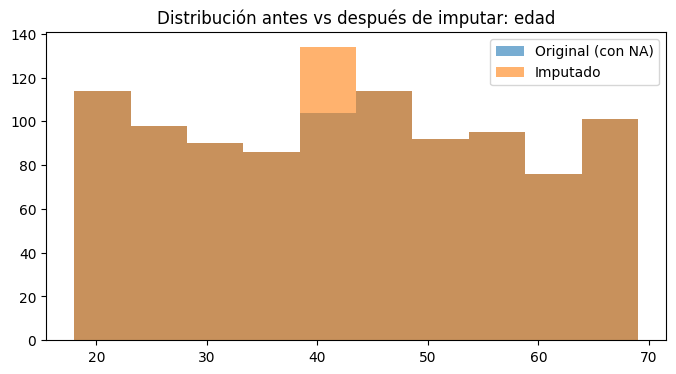

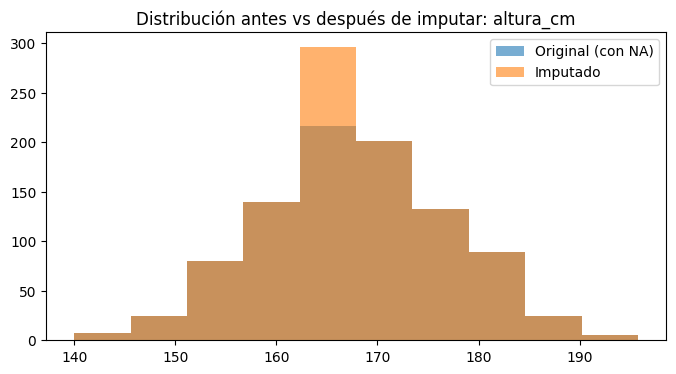

In [69]:
# --- Comparación visual entre original vs imputado ---
variables = ["edad", "altura_cm"]

for var in variables:
    plt.figure(figsize=(8,4))
    plt.hist(df[var].dropna(), bins=10, alpha=0.6, label="Original (con NA)")
    plt.hist(df_imputado[var], bins=10, alpha=0.6, label="Imputado")
    plt.title(f"Distribución antes vs después de imputar: {var}")
    plt.legend()
    plt.show()


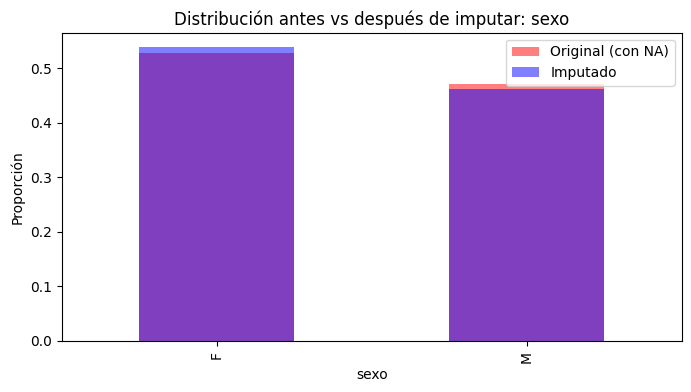

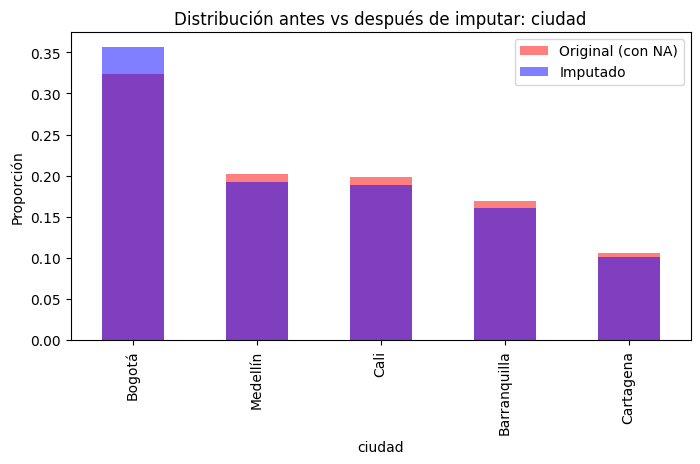

In [70]:
import matplotlib.pyplot as plt

cat_vars = ["sexo", "ciudad"]

for var in cat_vars:
    plt.figure(figsize=(8,4))
    
    # Distribución original (sin imputar)
    df[var].value_counts(normalize=True).plot(kind="bar", alpha=0.5, color="red", label="Original (con NA)")
    
    # Distribución imputada
    df_imputado[var].value_counts(normalize=True).plot(kind="bar", alpha=0.5, color="blue", label="Imputado")
    
    plt.title(f"Distribución antes vs después de imputar: {var}")
    plt.ylabel("Proporción")
    plt.legend()
    plt.show()


In [71]:
from scipy.stats import ks_2samp, mannwhitneyu

variables = ["edad", "altura_cm", "ingresos"]

print("=== Comparación de distribuciones antes vs después de imputar ===")
for var in variables:
    original = df[var].dropna()
    imputada = df_imputado[var]

    # Kolmogorov-Smirnov de dos muestras
    ks_stat, ks_p = ks_2samp(original, imputada)

    # Mann-Whitney U (medianas)
    mw_stat, mw_p = mannwhitneyu(original, imputada, alternative="two-sided")

    print(f"\nVariable: {var}")
    print(f" KS test: stat={ks_stat:.3f}, p={ks_p:.4f} → {'Distribuciones similares' if ks_p>0.05 else 'Distribuciones diferentes'}")
    print(f" Mann-Whitney U: U={mw_stat:.3f}, p={mw_p:.4f} → {'Medianas iguales' if mw_p>0.05 else 'Medianas diferentes'}")


=== Comparación de distribuciones antes vs después de imputar ===

Variable: edad
 KS test: stat=0.015, p=0.9998 → Distribuciones similares
 Mann-Whitney U: U=485075.000, p=0.9953 → Medianas iguales

Variable: altura_cm
 KS test: stat=0.040, p=0.4079 → Distribuciones similares
 Mann-Whitney U: U=459840.000, p=0.9895 → Medianas iguales

Variable: ingresos
 KS test: stat=nan, p=nan → Distribuciones diferentes
 Mann-Whitney U: U=nan, p=nan → Medianas diferentes


In [72]:
# =========================================================
# PRUEBAS ESTADÍSTICAS: ¿cambió la distribución tras imputar?
# =========================================================
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp, mannwhitneyu, ttest_ind, chi2_contingency

alpha = 0.05

# === 1) Variables NUMÉRICAS (usar método de tendencia central adecuado)
# Según tu diagnóstico: altura_cm ~ normal  -> t de Welch
#                       edad       no normal -> Mann–Whitney
num_normal    = ["altura_cm"]
num_nonnormal = ["edad"]

print("=== NUMÉRICAS: Comparación antes (df) vs después (df_imputado) ===")
for var in num_normal + num_nonnormal:
    x0 = df[var].dropna()          # original sin NA
    x1 = df_imputado[var]          # imputado (no debe tener NA si ya imputaste esa col.)

    # KS de dos muestras (distribución completa)
    ks_stat, ks_p = ks_2samp(x0, x1)

    # Prueba de tendencia central
    if var in num_normal:
        # t de Welch (medias, varianzas desiguales)
        t_stat, t_p = ttest_ind(x0, x1, equal_var=False, nan_policy="omit")
        trend_name, stat_fmt, p_trend = "t de Welch (medias)", f"t={t_stat:.3f}", t_p
    else:
        # Mann-Whitney U (medianas, no paramétrica)
        u_stat, u_p = mannwhitneyu(x0, x1, alternative="two-sided")
        trend_name, stat_fmt, p_trend = "Mann–Whitney U (medianas)", f"U={u_stat:.1f}", u_p

    print(f"\nVariable: {var}")
    print(f"  KS 2-samples: D={ks_stat:.3f}, p={ks_p:.4f}  -> "
          f"{'NO se detecta cambio (p≥0.05)' if ks_p>=alpha else 'SÍ cambia la distribución (p<0.05)'}")
    print(f"  {trend_name}: {stat_fmt}, p={p_trend:.4f} -> "
          f"{'Sin diferencia significativa' if p_trend>=alpha else 'Diferencia significativa'}")



=== NUMÉRICAS: Comparación antes (df) vs después (df_imputado) ===

Variable: altura_cm
  KS 2-samples: D=0.040, p=0.4079  -> NO se detecta cambio (p≥0.05)
  t de Welch (medias): t=0.000, p=1.0000 -> Sin diferencia significativa

Variable: edad
  KS 2-samples: D=0.015, p=0.9998  -> NO se detecta cambio (p≥0.05)
  Mann–Whitney U (medianas): U=485075.0, p=0.9953 -> Sin diferencia significativa


C:\Users\migue\AppData\Local\Temp\ipykernel_6372\1215494536.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[var], ax=axes[0], palette="pastel")
C:\Users\migue\AppData\Local\Temp\ipykernel_6372\1215494536.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_imputado[var], ax=axes[1], palette="muted")


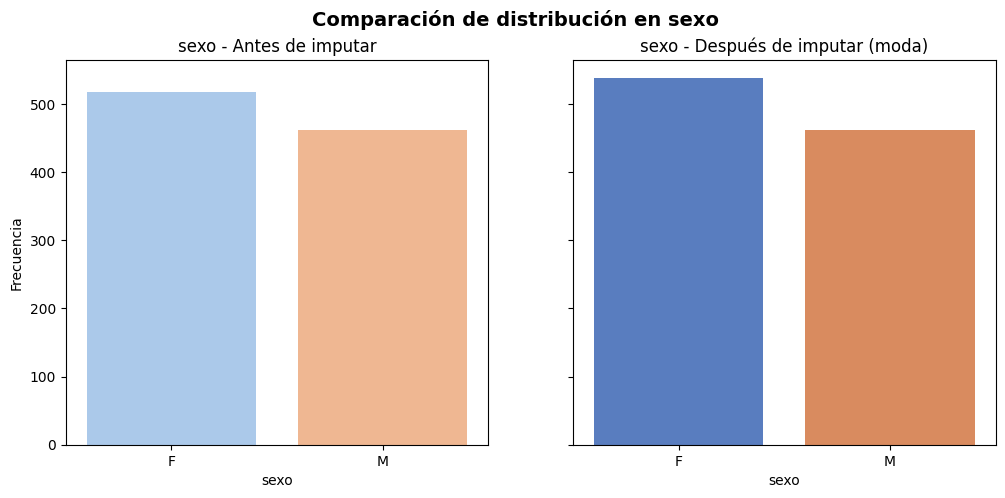

=== sexo ===
Proporciones antes:
 sexo
F    0.529
M    0.471
Name: count, dtype: float64
Proporciones después:
 sexo
F    0.538
M    0.462
Name: count, dtype: float64
Chi2 = 0.141, gl = 1, p = 0.7074 → No se rechaza H0 (distribuciones iguales)
------------------------------------------------------------


C:\Users\migue\AppData\Local\Temp\ipykernel_6372\1215494536.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[var], ax=axes[0], palette="pastel")
C:\Users\migue\AppData\Local\Temp\ipykernel_6372\1215494536.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_imputado[var], ax=axes[1], palette="muted")


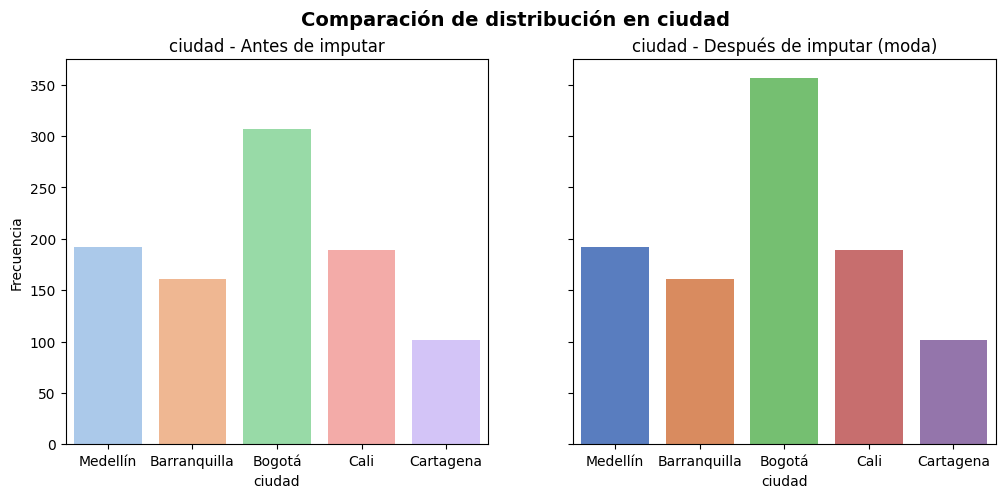

=== ciudad ===
Proporciones antes:
 ciudad
Barranquilla    0.169
Bogotá          0.323
Cali            0.199
Cartagena       0.106
Medellín        0.202
Name: count, dtype: float64
Proporciones después:
 ciudad
Barranquilla    0.161
Bogotá          0.357
Cali            0.189
Cartagena       0.101
Medellín        0.192
Name: count, dtype: float64
Chi2 = 2.485, gl = 4, p = 0.6474 → No se rechaza H0 (distribuciones iguales)
------------------------------------------------------------


In [73]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2_contingency

variables = ["sexo", "ciudad"]

for var in variables:
    # --- Gráficos comparativos ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    sns.countplot(x=df[var], ax=axes[0], palette="pastel")
    axes[0].set_title(f"{var} - Antes de imputar")
    axes[0].set_ylabel("Frecuencia")

    sns.countplot(x=df_imputado[var], ax=axes[1], palette="muted")
    axes[1].set_title(f"{var} - Después de imputar (moda)")
    axes[1].set_ylabel("Frecuencia")

    plt.suptitle(f"Comparación de distribución en {var}", fontsize=14, weight="bold")
    plt.show()

    # --- Chi-cuadrado ---
    orig_counts = df[var].value_counts().sort_index()
    imp_counts  = df_imputado[var].value_counts().sort_index()

    # Alinear categorías en caso de que falten
    orig_counts, imp_counts = orig_counts.align(imp_counts, fill_value=0)

    tabla = pd.DataFrame({"original": orig_counts, "imputada": imp_counts}).T

    chi2, p, dof, expected = chi2_contingency(tabla)

    print(f"=== {var} ===")
    print("Proporciones antes:\n", (orig_counts / orig_counts.sum()).round(3))
    print("Proporciones después:\n", (imp_counts / imp_counts.sum()).round(3))
    print(f"Chi2 = {chi2:.3f}, gl = {dof}, p = {p:.4f} → "
          f"{'No se rechaza H0 (distribuciones iguales)' if p > 0.05 else 'Se rechaza H0 (distribuciones diferentes)'}")
    print("-"*60)


In [74]:
# Conteo de NA en el df imputado
faltantes_df = df_imputado.isna().sum().sort_values(ascending=False)
faltantes_pct = (df_imputado.isna().mean() * 100).sort_values(ascending=False)

faltantes_resumen = pd.DataFrame({
    "Nulos": faltantes_df,
    "Porcentaje (%)": faltantes_pct.round(2)
})

print("=== Resumen de valores nulos después de imputar ===")
print(faltantes_resumen)


=== Resumen de valores nulos después de imputar ===
                    Nulos  Porcentaje (%)
puntuacion_credito    500            50.0
estado_civil          350            35.0
gasto_mensual         250            25.0
segmento              200            20.0
demanda               150            15.0
ingresos              120            12.0
nivel_educativo       100            10.0
fecha                   0             0.0
ciudad                  0             0.0
sexo                    0             0.0
altura_cm               0             0.0
edad                    0             0.0


=== Pruebas de normalidad ===

Variable: ingresos
  KS: D=0.019, p=0.8950 → Normal
  D’Agostino: χ²=0.965, p=0.6174 → Normal


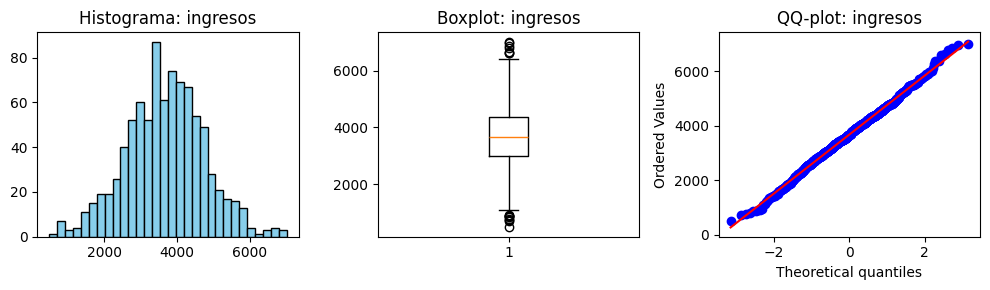


Variable: demanda
  KS: D=0.050, p=0.0260 → No normal
  D’Agostino: χ²=86.154, p=0.0000 → No normal


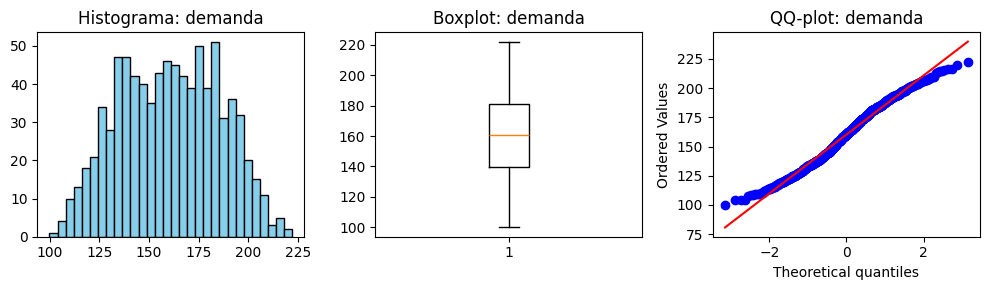

In [75]:
from scipy.stats import kstest, normaltest, probplot
import matplotlib.pyplot as plt

variables = ["ingresos", "demanda"]

print("=== Pruebas de normalidad ===")
for var in variables:
    datos = df[var].dropna()  # quitamos NA

    # Kolmogorov-Smirnov contra N(media, sd)
    ks_stat, ks_p = kstest(datos, "norm", args=(datos.mean(), datos.std(ddof=1)))

    # D’Agostino-Pearson (n>20)
    dag_stat, dag_p = normaltest(datos)

    print(f"\nVariable: {var}")
    print(f"  KS: D={ks_stat:.3f}, p={ks_p:.4f} → {'Normal' if ks_p>0.05 else 'No normal'}")
    print(f"  D’Agostino: χ²={dag_stat:.3f}, p={dag_p:.4f} → {'Normal' if dag_p>0.05 else 'No normal'}")

    # --- Gráficos ---
    plt.figure(figsize=(10,3))
    
    plt.subplot(1,3,1)
    plt.hist(datos, bins=30, color="skyblue", edgecolor="black")
    plt.title(f"Histograma: {var}")

    plt.subplot(1,3,2)
    plt.boxplot(datos, vert=True)
    plt.title(f"Boxplot: {var}")

    plt.subplot(1,3,3)
    probplot(datos, dist="norm", plot=plt)
    plt.title(f"QQ-plot: {var}")

    plt.tight_layout()
    plt.show()


In [76]:
from sklearn.impute import SimpleImputer

# Copia del df imputado anterior (para no perder lo que ya hicimos con edad, altura_cm, sexo, ciudad)
df_imp3 = df_imputado.copy()

# --- Categóricas ---
imp_moda = SimpleImputer(strategy="most_frequent")
df_imp3[["segmento"]] = imp_moda.fit_transform(df_imp3[["segmento"]])
df_imp3[["nivel_educativo"]] = imp_moda.fit_transform(df_imp3[["nivel_educativo"]])

# --- Numéricas ---
# ingresos (normal) -> media
imp_media = SimpleImputer(strategy="mean")
df_imp3[["ingresos"]] = imp_media.fit_transform(df_imp3[["ingresos"]])

# demanda (no normal) -> mediana
imp_mediana = SimpleImputer(strategy="median")
df_imp3[["demanda"]] = imp_mediana.fit_transform(df_imp3[["demanda"]])

# --- Verificación ---
print("Valores nulos después de imputar estas 4 variables:")
print(df_imp3[["segmento", "nivel_educativo", "ingresos", "demanda"]].isna().sum())


Valores nulos después de imputar estas 4 variables:
segmento           0
nivel_educativo    0
ingresos           0
demanda            0
dtype: int64


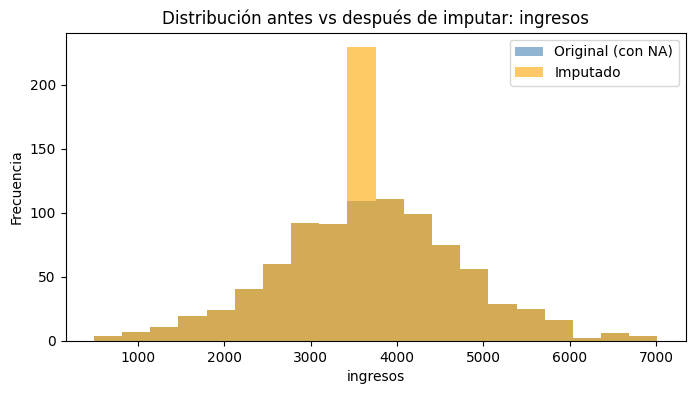

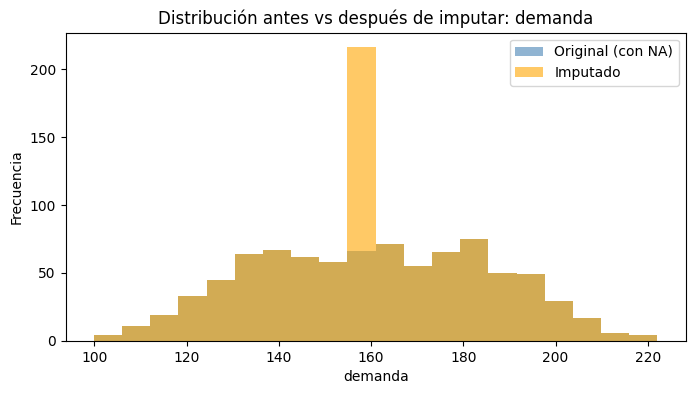

In [77]:
import matplotlib.pyplot as plt

# Variables numéricas recién imputadas
variables_num = ["ingresos", "demanda"]

for var in variables_num:
    plt.figure(figsize=(8,4))
    plt.hist(df[var].dropna(), bins=20, alpha=0.6, label="Original (con NA)", color="steelblue")
    plt.hist(df_imp3[var], bins=20, alpha=0.6, label="Imputado", color="orange")
    plt.title(f"Distribución antes vs después de imputar: {var}")
    plt.xlabel(var)
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.show()



In [78]:
# =========================================================
# PRUEBAS ESTADÍSTICAS: ¿cambió la distribución tras imputar?
# =========================================================
from scipy.stats import ks_2samp, mannwhitneyu, ttest_ind

alpha = 0.05

num_normal    = ["ingresos"]
num_nonnormal = ["demanda"]

print("=== NUMÉRICAS: Comparación antes (df) vs después (df_imp3) ===")
for var in num_normal + num_nonnormal:
    x0 = df[var].dropna()          # original sin NA
    x1 = df_imp3[var]              # imputado (ya sin NA)

    # KS de dos muestras (distribución completa)
    ks_stat, ks_p = ks_2samp(x0, x1)

    # Prueba de tendencia central
    if var in num_normal:
        # t de Welch (para normales)
        t_stat, t_p = ttest_ind(x0, x1, equal_var=False, nan_policy="omit")
        trend_name, stat_fmt, p_trend = "t de Welch (medias)", f"t={t_stat:.3f}", t_p
    else:
        # Mann-Whitney U (para no normales)
        u_stat, u_p = mannwhitneyu(x0, x1, alternative="two-sided")
        trend_name, stat_fmt, p_trend = "Mann–Whitney U (medianas)", f"U={u_stat:.1f}", u_p

    print(f"\nVariable: {var}")
    print(f"  KS 2-samples: D={ks_stat:.3f}, p={ks_p:.4f}  -> "
          f"{'NO se detecta cambio (p≥0.05)' if ks_p>=alpha else 'SÍ cambia la distribución (p<0.05)'}")
    print(f"  {trend_name}: {stat_fmt}, p={p_trend:.4f} -> "
          f"{'Sin diferencia significativa' if p_trend>=alpha else 'Diferencia significativa'}")


=== NUMÉRICAS: Comparación antes (df) vs después (df_imp3) ===

Variable: ingresos
  KS 2-samples: D=0.060, p=0.0633  -> NO se detecta cambio (p≥0.05)
  t de Welch (medias): t=0.000, p=1.0000 -> Sin diferencia significativa

Variable: demanda
  KS 2-samples: D=0.075, p=0.0107  -> SÍ cambia la distribución (p<0.05)
  Mann–Whitney U (medianas): U=425000.0, p=1.0000 -> Sin diferencia significativa


C:\Users\migue\AppData\Local\Temp\ipykernel_6372\4174160545.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[var], ax=axes[0], palette="pastel")
C:\Users\migue\AppData\Local\Temp\ipykernel_6372\4174160545.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_imp3[var], ax=axes[1], palette="muted")


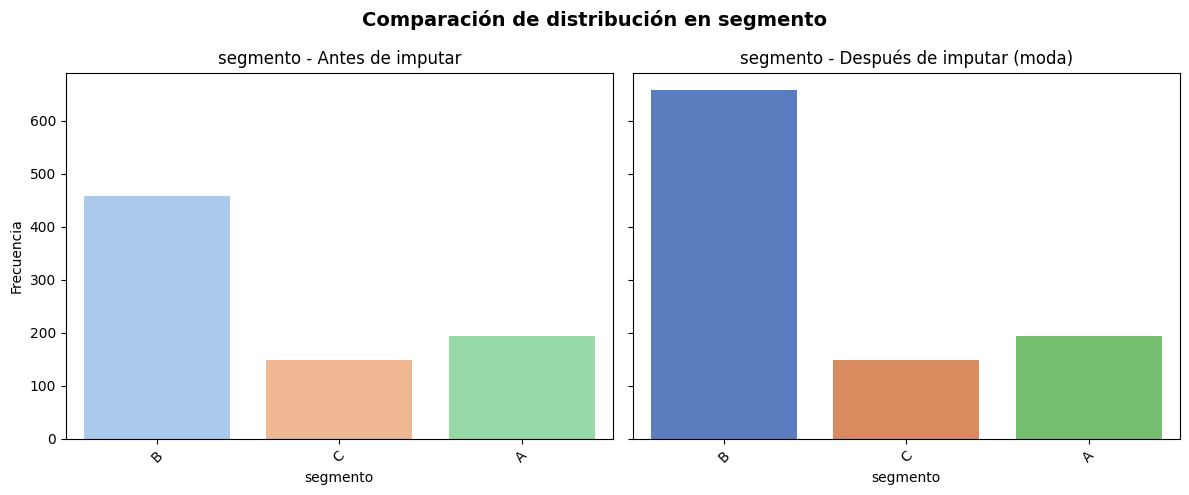

C:\Users\migue\AppData\Local\Temp\ipykernel_6372\4174160545.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[var], ax=axes[0], palette="pastel")


=== segmento ===
Proporciones antes:
 segmento
A    0.242
B    0.571
C    0.186
Name: count, dtype: float64
Proporciones después:
 segmento
A    0.194
B    0.657
C    0.149
Name: count, dtype: float64
Chi2 = 13.855, gl = 2, p = 0.0010 → Se rechaza H0 (distribuciones diferentes)
------------------------------------------------------------


C:\Users\migue\AppData\Local\Temp\ipykernel_6372\4174160545.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_imp3[var], ax=axes[1], palette="muted")


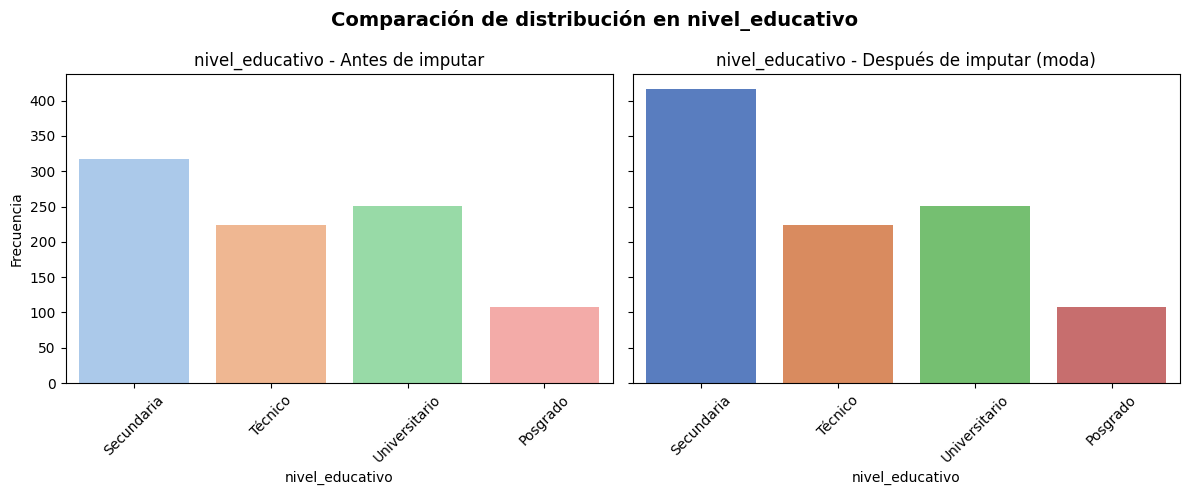

=== nivel_educativo ===
Proporciones antes:
 nivel_educativo
Posgrado         0.120
Secundaria       0.352
Técnico          0.249
Universitario    0.279
Name: count, dtype: float64
Proporciones después:
 nivel_educativo
Posgrado         0.108
Secundaria       0.417
Técnico          0.224
Universitario    0.251
Name: count, dtype: float64
Chi2 = 8.384, gl = 3, p = 0.0387 → Se rechaza H0 (distribuciones diferentes)
------------------------------------------------------------


In [79]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2_contingency

# Categóricas recién imputadas
variables = ["segmento", "nivel_educativo"]

for var in variables:
    # --- Gráficos comparativos ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    sns.countplot(x=df[var], ax=axes[0], palette="pastel")
    axes[0].set_title(f"{var} - Antes de imputar")
    axes[0].set_ylabel("Frecuencia")
    axes[0].tick_params(axis="x", rotation=45)

    sns.countplot(x=df_imp3[var], ax=axes[1], palette="muted")
    axes[1].set_title(f"{var} - Después de imputar (moda)")
    axes[1].set_ylabel("Frecuencia")
    axes[1].tick_params(axis="x", rotation=45)

    plt.suptitle(f"Comparación de distribución en {var}", fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()

    # --- Chi-cuadrado (distribuciones antes vs después) ---
    orig_counts = df[var].value_counts().sort_index()
    imp_counts  = df_imp3[var].value_counts().sort_index()

    # Alinear categorías (por si alguna aparece solo en una de las versiones)
    orig_counts, imp_counts = orig_counts.align(imp_counts, fill_value=0)

    # Matriz 2 x k (filas: original/imputada; columnas: categorías)
    tabla = pd.DataFrame({"original": orig_counts, "imputada": imp_counts}).T

    chi2, p, dof, expected = chi2_contingency(tabla)

    print(f"=== {var} ===")
    print("Proporciones antes:\n", (orig_counts / orig_counts.sum()).round(3))
    print("Proporciones después:\n", (imp_counts / imp_counts.sum()).round(3))
    print(f"Chi2 = {chi2:.3f}, gl = {dof}, p = {p:.4f} → "
          f"{'No se rechaza H0 (distribuciones iguales)' if p > 0.05 else 'Se rechaza H0 (distribuciones diferentes)'}")
    print("-"*60)


In [80]:
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

# =========================
# 1) Dataset base: df_imp4
# =========================
# Partimos del df_imputado (ya trae: edad=mediana, altura_cm=media, sexo/ciudad=moda)
df_imp4 = df_imputado.copy()

# --- Numéricas ya acordadas ---
# ingresos (normal) -> media
imp_media = SimpleImputer(strategy="mean")
df_imp4[["ingresos"]] = imp_media.fit_transform(df_imp4[["ingresos"]])

# demanda (no normal) -> mediana
imp_mediana = SimpleImputer(strategy="median")
df_imp4[["demanda"]] = imp_mediana.fit_transform(df_imp4[["demanda"]])

# 🚫 OJO: NO imputamos 'segmento' ni 'nivel_educativo' aquí.
# Quedan con NA para aplicar Hot-Deck y comparar contra la imputación por moda.

print("NA en df_imp4 (después de imputar SOLO numéricas):")
print(df_imp4.isna().sum().sort_values(ascending=False))

NA en df_imp4 (después de imputar SOLO numéricas):
puntuacion_credito    500
estado_civil          350
gasto_mensual         250
segmento              200
nivel_educativo       100
ciudad                  0
fecha                   0
sexo                    0
altura_cm               0
edad                    0
ingresos                0
demanda                 0
dtype: int64


In [81]:
import numpy as np
import pandas as pd

# --------------------------------------------------
# Función genérica de hot-deck aleatorio por grupos
# --------------------------------------------------
def hot_deck_random(df, target, group_vars=None, seed=42):
    np.random.seed(seed)
    df_copy = df.copy()

    if group_vars is None:
        na_index = df_copy[df_copy[target].isna()].index
        donors = df_copy[target].dropna().values
        df_copy.loc[na_index, target] = np.random.choice(donors, size=len(na_index), replace=True)
    else:
        for keys, group in df_copy.groupby(group_vars):
            na_index = group[group[target].isna()].index
            donors = group[target].dropna().values

            if len(na_index) > 0:
                if len(donors) == 0:
                    # Caso: el grupo no tiene donantes → usar globales
                    donors = df_copy[target].dropna().values
                df_copy.loc[na_index, target] = np.random.choice(donors, size=len(na_index), replace=True)

        # 🔥 Imputar cualquier NA restante con donantes globales
        if df_copy[target].isna().sum() > 0:
            na_index = df_copy[df_copy[target].isna()].index
            donors = df_copy[target].dropna().values
            df_copy.loc[na_index, target] = np.random.choice(donors, size=len(na_index), replace=True)

    return df_copy



# ==================================================
# Imputación con hot-deck
# ==================================================

# Copia del dataset original
df_imp_hd = df_imp4.copy()

# Imputar 'segmento' usando 'nivel_educativo' como agrupador
df_imp_hd = hot_deck_random(df_imp_hd, target="segmento", group_vars=["nivel_educativo"])

# Imputar 'nivel_educativo' usando 'segmento' como agrupador
#df_imp_hd = hot_deck_random(df_imp_hd, target="nivel_educativo", group_vars=["segmento"])

# --------------------------------------------------
# Verificación rápida
# --------------------------------------------------
print("NA después de imputar:")
print(df_imp_hd[["segmento", "nivel_educativo"]].isna().sum(), "\n")

print("Distribución 'segmento':")
print(df_imp_hd["segmento"].value_counts(normalize=True).round(3), "\n")

#print("Distribución 'nivel_educativo':")
#print(df_imp_hd["nivel_educativo"].value_counts(normalize=True).round(3))


NA después de imputar:
segmento             0
nivel_educativo    100
dtype: int64 

Distribución 'segmento':
segmento
B    0.575
A    0.237
C    0.188
Name: proportion, dtype: float64 



In [82]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

# Copia del dataset
df_knn = df_imp_hd .copy()

# Variables predictoras: numéricas asociadas (altura y demanda) + opcionales
X = df_knn[["altura_cm", "demanda"]]
y = df_knn["nivel_educativo"]

# Casos completos (train para entrenar el clasificador)
mask = y.notna()
X_train, y_train = X[mask], y[mask]

# Casos con NA (para predecirlos)
X_missing = X[~mask]

# Entrenar KNN
knn = KNeighborsClassifier(n_neighbors=5, weights="distance")
knn.fit(X_train, y_train)

# Predecir valores faltantes
y_pred = knn.predict(X_missing)

# Reemplazar en el dataset
df_knn.loc[~mask, "nivel_educativo"] = y_pred

# Agregar flag de imputación (opcional)
df_knn["nivel_educativo_flag"] = (~mask).astype(int)

print("NA restantes:", df_knn["nivel_educativo"].isna().sum())
print("Distribución antes y después de imputar:")
print(df["nivel_educativo"].value_counts(normalize=True).round(3))
print(df_knn["nivel_educativo"].value_counts(normalize=True).round(3))


NA restantes: 0
Distribución antes y después de imputar:
nivel_educativo
Secundaria       0.352
Universitario    0.279
Técnico          0.249
Posgrado         0.120
Name: proportion, dtype: float64
nivel_educativo
Secundaria       0.358
Universitario    0.277
Técnico          0.248
Posgrado         0.117
Name: proportion, dtype: float64


C:\Users\migue\AppData\Local\Temp\ipykernel_6372\3847799516.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[var], ax=axes[0], palette="pastel")
C:\Users\migue\AppData\Local\Temp\ipykernel_6372\3847799516.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_imputado[var], ax=axes[1], palette="muted")


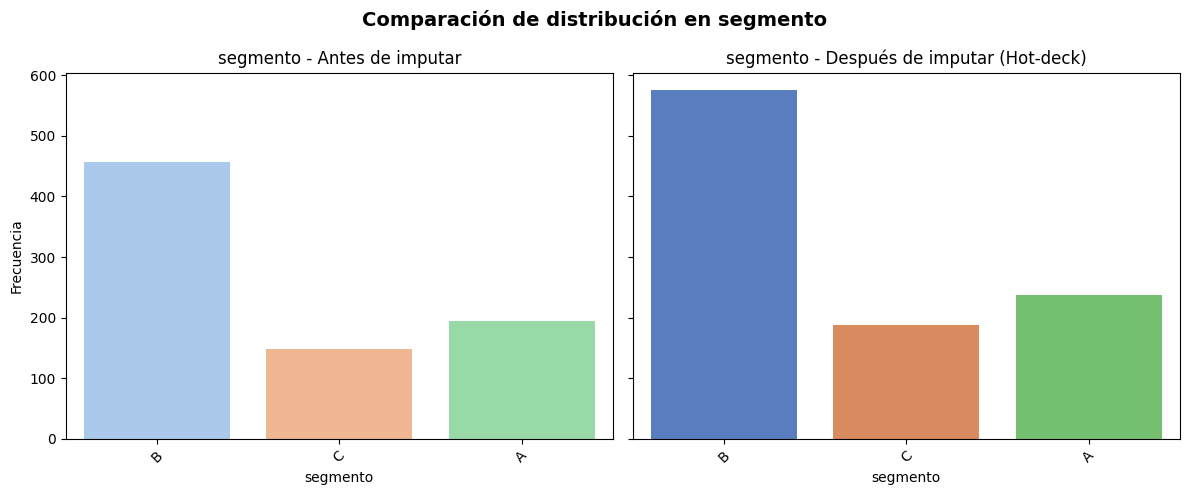

=== segmento — Método: Hot-deck ===
Proporciones antes:
 segmento
A    0.242
B    0.571
C    0.186
Name: count, dtype: float64
Proporciones después:
 segmento
A    0.237
B    0.575
C    0.188
Name: count, dtype: float64
Chi2 = 0.074, gl = 2, p = 0.9635 → No se rechaza H0 (distribuciones iguales)
------------------------------------------------------------


C:\Users\migue\AppData\Local\Temp\ipykernel_6372\3847799516.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[var], ax=axes[0], palette="pastel")
C:\Users\migue\AppData\Local\Temp\ipykernel_6372\3847799516.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_imputado[var], ax=axes[1], palette="muted")


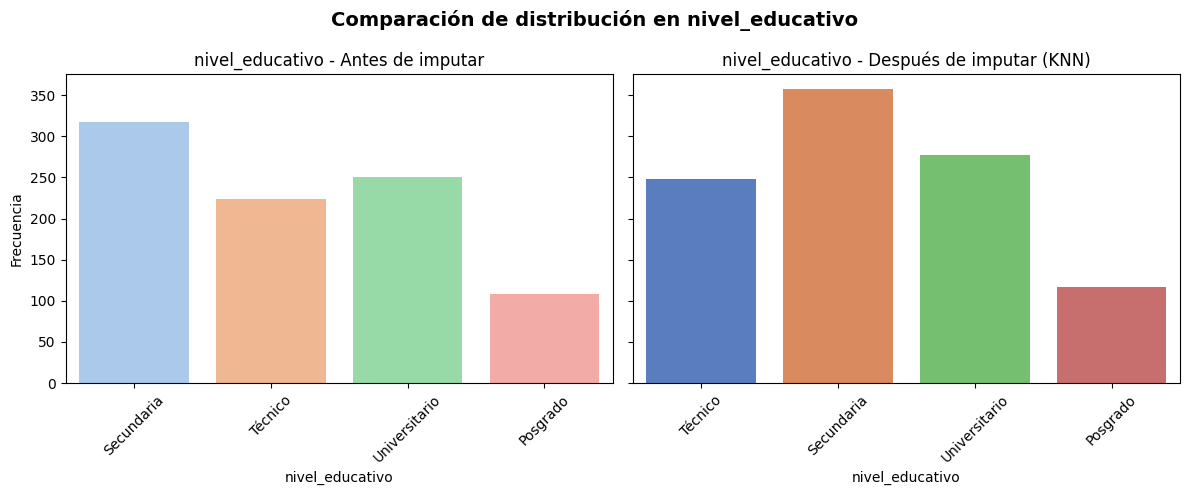

=== nivel_educativo — Método: KNN ===
Proporciones antes:
 nivel_educativo
Posgrado         0.120
Secundaria       0.352
Técnico          0.249
Universitario    0.279
Name: count, dtype: float64
Proporciones después:
 nivel_educativo
Posgrado         0.117
Secundaria       0.358
Técnico          0.248
Universitario    0.277
Name: count, dtype: float64
Chi2 = 0.088, gl = 3, p = 0.9932 → No se rechaza H0 (distribuciones iguales)
------------------------------------------------------------


In [93]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2_contingency

# ============================
# Configura aquí tu imputado 👇
# ============================
df_imputado  = df_knn     # DataFrame final imputado

# Métodos aplicados por variable
metodos = {
    "segmento": "Hot-deck",
    "nivel_educativo": "KNN"
}

# Categóricas recién imputadas
variables = ["segmento", "nivel_educativo"]

for var in variables:
    label_metodo = metodos[var]

    # --- Gráficos comparativos ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    sns.countplot(x=df[var], ax=axes[0], palette="pastel")
    axes[0].set_title(f"{var} - Antes de imputar")
    axes[0].set_ylabel("Frecuencia")
    axes[0].tick_params(axis="x", rotation=45)

    sns.countplot(x=df_imputado[var], ax=axes[1], palette="muted")
    axes[1].set_title(f"{var} - Después de imputar ({label_metodo})")
    axes[1].set_ylabel("Frecuencia")
    axes[1].tick_params(axis="x", rotation=45)

    plt.suptitle(f"Comparación de distribución en {var}", fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()

    # --- Chi-cuadrado (distribuciones antes vs después) ---
    orig_counts = df[var].value_counts().sort_index()
    imp_counts  = df_imputado[var].value_counts().sort_index()
    orig_counts, imp_counts = orig_counts.align(imp_counts, fill_value=0)

    nonzero_cols = (orig_counts + imp_counts) > 0
    orig_counts = orig_counts[nonzero_cols]
    imp_counts  = imp_counts[nonzero_cols]

    tabla = pd.DataFrame({"original": orig_counts, "imputado": imp_counts}).T

    chi2, p, dof, expected = chi2_contingency(tabla)

    print(f"=== {var} — Método: {label_metodo} ===")
    print("Proporciones antes:\n", (orig_counts / orig_counts.sum()).round(3))
    print("Proporciones después:\n", (imp_counts / imp_counts.sum()).round(3))
    print(f"Chi2 = {chi2:.3f}, gl = {dof}, p = {p:.4f} → "
          f"{'No se rechaza H0 (distribuciones iguales)' if p > 0.05 else 'Se rechaza H0 (distribuciones diferentes)'}")
    print("-"*60)


In [84]:
# ===============================
# Conteo de NA por variable
# ===============================
na_totales = df_imputado.isna().sum().sort_values(ascending=False)
na_pct = (df_imputado.isna().mean() * 100).round(2)

na_df = pd.DataFrame({
    "Nulos": na_totales,
    "Porcentaje (%)": na_pct
}).sort_values(by="Nulos", ascending=False)

print("=== Resumen de valores nulos ===")
print(na_df)

print("\nResumen global:")
print("Total de NA en el dataset:", int(na_totales.sum()))



=== Resumen de valores nulos ===
                      Nulos  Porcentaje (%)
puntuacion_credito      500            50.0
estado_civil            350            35.0
gasto_mensual           250            25.0
altura_cm                 0             0.0
ciudad                    0             0.0
edad                      0             0.0
demanda                   0             0.0
ingresos                  0             0.0
fecha                     0             0.0
nivel_educativo           0             0.0
nivel_educativo_flag      0             0.0
segmento                  0             0.0
sexo                      0             0.0

Resumen global:
Total de NA en el dataset: 1100


In [85]:
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer

# ===============================
# 1) Base: mantener TODO lo hecho
# ===============================
# Parte del dataset más completo que ya tienes
df_imp5 = df_imputado.copy()

# =========================================
# 2) KNN SOLO para 'gasto_mensual'
#    (sin tocar otras columnas)
# =========================================

# Predictores candidatos (numéricos) para la vecindad
candidatos = ["edad", "ingresos", "altura_cm", "demanda"]
predictores = [c for c in candidatos if c in df_imp5.columns and np.issubdtype(df_imp5[c].dtype, np.number)]

# Armamos el bloque para KNN: 'gasto_mensual' + predictores
vars_for_knn = ["gasto_mensual"] + predictores

# Filtro por si 'gasto_mensual' no existe o no hay predictores válidos
if "gasto_mensual" in df_imp5.columns and len(vars_for_knn) > 1:
    # Copia temporal solo con esas columnas (todas numéricas)
    X = df_imp5[vars_for_knn].copy()

    # Si TODOS los valores de gasto_mensual fueran NA, usa mediana como respaldo
    if X["gasto_mensual"].isna().all():
        mediana_gm = np.nanmedian(X["gasto_mensual"])
        df_imp5["gasto_mensual"] = mediana_gm
    else:
        imputer = KNNImputer(n_neighbors=5)
        X_imputed = imputer.fit_transform(X)

        # Reemplaza SOLO la columna 'gasto_mensual' con lo imputado
        df_imp5["gasto_mensual"] = X_imputed[:, 0]
else:
    print("⚠️ KNN no aplicado: faltan predictores numéricos o la columna 'gasto_mensual'.")

# =========================================
# 3) Mantener 'puntuacion_credito' SIN imputar
#    + flag de NA (0/1)
# =========================================
if "puntuacion_credito" in df_imp5.columns:
    df_imp5["puntuacion_credito_missing"] = df_imp5["puntuacion_credito"].isna().astype(int)

# =========================================
# 4) Verificación: NA por variable
# =========================================
na_totales = df_imp5.isna().sum().sort_values(ascending=False)
na_pct = (df_imp5.isna().mean() * 100).round(2)

na_df = pd.DataFrame({
    "Nulos": na_totales,
    "Porcentaje (%)": na_pct
}).sort_values(by="Nulos", ascending=False)

print("=== Resumen de valores nulos en df_imp5 ===")
print(na_df)
print("\nResumen global:")
print("Total de NA en el dataset:", int(na_totales.sum()))


=== Resumen de valores nulos en df_imp5 ===
                            Nulos  Porcentaje (%)
puntuacion_credito            500            50.0
estado_civil                  350            35.0
ciudad                          0             0.0
demanda                         0             0.0
edad                            0             0.0
altura_cm                       0             0.0
fecha                           0             0.0
gasto_mensual                   0             0.0
nivel_educativo                 0             0.0
ingresos                        0             0.0
nivel_educativo_flag            0             0.0
puntuacion_credito_missing      0             0.0
segmento                        0             0.0
sexo                            0             0.0

Resumen global:
Total de NA en el dataset: 850


In [86]:
import numpy as np
import pandas as pd

# ===============================
# Hot-deck aleatorio por grupos
# ===============================
def hot_deck_random(df, target, group_vars=None, seed=42):
    np.random.seed(seed)
    df_copy = df.copy()

    if group_vars is None:
        # Simple: elegir de toda la columna
        na_index = df_copy[df_copy[target].isna()].index
        donors = df_copy[target].dropna().values
        if len(na_index) > 0 and len(donors) > 0:
            df_copy.loc[na_index, target] = np.random.choice(donors, size=len(na_index), replace=True)
    else:
        # Dentro de cada grupo
        for _, group in df_copy.groupby(group_vars):
            na_index = group[group[target].isna()].index
            donors = group[target].dropna().values
            if len(na_index) > 0:
                if len(donors) == 0:   # si no hay donantes en el grupo
                    donors = df_copy[target].dropna().values  # usar globales
                if len(donors) > 0:
                    df_copy.loc[na_index, target] = np.random.choice(donors, size=len(na_index), replace=True)

        # Rescate global si todavía quedan NA
        if df_copy[target].isna().sum() > 0:
            na_index = df_copy[df_copy[target].isna()].index
            donors = df_copy[target].dropna().values
            if len(donors) > 0:
                df_copy.loc[na_index, target] = np.random.choice(donors, size=len(na_index), replace=True)

    return df_copy

# ===============================
# Imputación de estado_civil
# ===============================
df_imp5 = hot_deck_random(df_imp5, target="estado_civil", group_vars=["sexo", "edad"])

# ===============================
# Verificación
# ===============================
print("NA restantes en estado_civil:", df_imp5["estado_civil"].isna().sum())
print("\nDistribución después de imputar:")
print(df_imp5["estado_civil"].value_counts(normalize=True).round(3))




NA restantes en estado_civil: 0

Distribución después de imputar:
estado_civil
Soltero/a       0.469
Casado/a        0.343
Unión libre     0.133
Divorciado/a    0.055
Name: proportion, dtype: float64


In [87]:
# ===============================
# Resumen final de NA en df_imp5
# ===============================
na_totales = df_imp5.isna().sum()
na_pct = (df_imp5.isna().mean() * 100).round(2)

na_df_final = pd.DataFrame({
    "Nulos": na_totales,
    "Porcentaje (%)": na_pct
}).sort_values(by="Nulos", ascending=False)

print("=== Resumen de valores nulos en df_imp5 (final) ===")
print(na_df_final)

print("\nResumen global:")
print("Total de NA en el dataset:", int(na_totales.sum()))


=== Resumen de valores nulos en df_imp5 (final) ===
                            Nulos  Porcentaje (%)
puntuacion_credito            500            50.0
fecha                           0             0.0
ciudad                          0             0.0
nivel_educativo                 0             0.0
segmento                        0             0.0
sexo                            0             0.0
estado_civil                    0             0.0
edad                            0             0.0
ingresos                        0             0.0
altura_cm                       0             0.0
gasto_mensual                   0             0.0
demanda                         0             0.0
nivel_educativo_flag            0             0.0
puntuacion_credito_missing      0             0.0

Resumen global:
Total de NA en el dataset: 500


In [88]:
# ===============================
# Comparación para gasto_mensual
# ===============================
from scipy.stats import ks_2samp, ttest_ind

alpha = 0.05

x0 = df["gasto_mensual"].dropna()   # original sin NA
x1 = df_imp5["gasto_mensual"]       # imputado con KNN

# KS 2 muestras
ks_stat, ks_p = ks_2samp(x0, x1)

# t de Welch
t_stat, t_p = ttest_ind(x0, x1, equal_var=False, nan_policy="omit")

print("=== gasto_mensual (KNN) ===")
print(f"KS 2-samples: D={ks_stat:.3f}, p={ks_p:.4f} -> "
      f"{'NO se detecta cambio' if ks_p>=alpha else 'SÍ cambia la distribución'}")
print(f"t de Welch (medias): t={t_stat:.3f}, p={t_p:.4f} -> "
      f"{'Sin diferencia significativa' if t_p>=alpha else 'Diferencia significativa'}")
print("-"*60)


=== gasto_mensual (KNN) ===
KS 2-samples: D=0.047, p=0.3000 -> NO se detecta cambio
t de Welch (medias): t=1.609, p=0.1078 -> Sin diferencia significativa
------------------------------------------------------------


In [89]:
# PRUEBAS ESTADÍSTICAS: ¿cambió la distribución tras imputar?
# =========================================================
from scipy.stats import ks_2samp, mannwhitneyu, ttest_ind, chi2_contingency

alpha = 0.05

# -------------------------------
# 1) Categórica: estado_civil
# -------------------------------
def prueba_chi2(original, imputado, var, label="Imputado"):
    orig_counts = original[var].value_counts().sort_index()
    imp_counts  = imputado[var].value_counts().sort_index()
    orig_counts, imp_counts = orig_counts.align(imp_counts, fill_value=0)

    nonzero = (orig_counts + imp_counts) > 0
    orig_counts, imp_counts = orig_counts[nonzero], imp_counts[nonzero]

    tabla = pd.DataFrame({"original": orig_counts, "imputado": imp_counts}).T
    chi2, p, dof, _ = chi2_contingency(tabla)

    print(f"=== {var} ({label}) ===")
    print("Proporciones antes:\n", (orig_counts / orig_counts.sum()).round(3))
    print("Proporciones después:\n", (imp_counts / imp_counts.sum()).round(3))
    print(f"Chi2 = {chi2:.3f}, gl = {dof}, p = {p:.4f} → "
          f"{'NO se detecta cambio' if p>=alpha else 'SÍ cambia la distribución'}")
    print("-"*60)

prueba_chi2(df, df_imp5, "estado_civil", "Hot-deck")

=== estado_civil (Hot-deck) ===
Proporciones antes:
 estado_civil
Casado/a        0.355
Divorciado/a    0.055
Soltero/a       0.446
Unión libre     0.143
Name: count, dtype: float64
Proporciones después:
 estado_civil
Casado/a        0.343
Divorciado/a    0.055
Soltero/a       0.469
Unión libre     0.133
Name: count, dtype: float64
Chi2 = 0.914, gl = 3, p = 0.8221 → NO se detecta cambio
------------------------------------------------------------


In [91]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu

def _safe_chi2(miss_indicator, cat_series):
    """Chi2 para (missing vs categoría), manejando niveles vacíos."""
    tab = pd.crosstab(miss_indicator, cat_series, dropna=True)
    # Requiere al menos 2 columnas (2 categorías) y 2 filas (miss/no-miss)
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        return np.nan
    try:
        chi2, p, dof, exp = chi2_contingency(tab)
        return p
    except Exception:
        return np.nan

def _safe_t_and_mwna(miss_indicator, num_series):
    """Welch t-test y Mann-Whitney entre grupos (NA vs no-NA)."""
    g_na  = num_series[miss_indicator].dropna()
    g_ok  = num_series[~miss_indicator].dropna()
    # Se requieren al menos algunos datos en ambos grupos
    if len(g_na) < 5 or len(g_ok) < 5:
        return np.nan, np.nan
    try:
        # Welch t-test (equal_var=False)
        t_p = ttest_ind(g_na, g_ok, equal_var=False, nan_policy="omit").pvalue
    except Exception:
        t_p = np.nan
    try:
        mw_p = mannwhitneyu(g_na, g_ok, alternative="two-sided").pvalue
    except Exception:
        mw_p = np.nan
    return t_p, mw_p

def test_missing_randomness(
    df,
    target_vars=("sexo", "segmento", "nivel_educativo"),
    alpha=0.05,
    exclude=("fecha", "puntuacion_credito"),
    min_non_na_per_group=5
):
    # Detectar tipos
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

    # Excluir columnas indicadas y la propia target
    numeric_cols = [c for c in numeric_cols if c not in exclude]
    cat_cols     = [c for c in cat_cols     if c not in exclude]

    results = {}
    summaries = []

    for tv in target_vars:
        miss = df[tv].isna()
        # Evitar usar la misma target como covariable
        num_covs = [c for c in numeric_cols if c != tv]
        cat_covs = [c for c in cat_cols     if c != tv]

        # --- Numéricas ---
        num_rows = []
        for c in num_covs:
            t_p, mw_p = _safe_t_and_mwna(miss, df[c])
            num_rows.append({
                "target": tv,
                "covariable": c,
                "test": "Welch t-test / Mann-Whitney",
                "p_ttest": t_p,
                "p_mw": mw_p,
                "evid_asociacion": ( (not np.isnan(t_p) and t_p < alpha) or (not np.isnan(mw_p) and mw_p < alpha) )
            })
        df_num = pd.DataFrame(num_rows)

        # --- Categóricas ---
        cat_rows = []
        for c in cat_covs:
            p = _safe_chi2(miss, df[c])
            cat_rows.append({
                "target": tv,
                "covariable": c,
                "test": "Chi-cuadrado",
                "p_chi2": p,
                "evid_asociacion": (not np.isnan(p) and p < alpha)
            })
        df_cat = pd.DataFrame(cat_rows)

        # Resumen por target
        min_p_num = np.nanmin(
            np.array(
                [x for x in pd.concat([
                    df_num["p_ttest"], df_num["p_mw"]
                ], ignore_index=True).values if not pd.isna(x)]
            )
        ) if not df_num.empty else np.nan

        min_p_cat = np.nanmin(
            df_cat["p_chi2"].values[~pd.isna(df_cat["p_chi2"].values)]
        ) if not df_cat.empty else np.nan

        any_assoc = (
            (not np.isnan(min_p_num) and min_p_num < alpha) or
            (not np.isnan(min_p_cat) and min_p_cat < alpha)
        )

        conclusion = (
            "EVIDENCIA de dependencia (→ probablemente MAR/NMAR)"
            if any_assoc else
            "Sin evidencia de dependencia (→ consistente con MCAR respecto a covariables evaluadas)"
        )

        summaries.append({
            "target": tv,
            "min_p_num": min_p_num,
            "min_p_cat": min_p_cat,
            "alpha": alpha,
            "conclusion": conclusion
        })

        results[tv] = {"numericas": df_num, "categoricas": df_cat}

    summary_df = pd.DataFrame(summaries)
    return results, summary_df

# =========================
# USO:
# =========================
# Ajusta si quieres excluir/añadir columnas específicas
targets = ["sexo", "segmento", "nivel_educativo"]
results, resumen = test_missing_randomness(
    df,
    target_vars=targets,
    alpha=0.05,
    exclude=("fecha", "puntuacion_credito")  # agrega aquí cualquier columna que no quieras usar como covariable
)

# 'resumen' te da una vista rápida (min p-values y conclusión por target)
print("\n=== RESUMEN (MCAR vs MAR/NMAR) ===")
print(resumen)

# Si quieres ver el detalle por target:
for tv in targets:
    print(f"\n--- Detalle {tv}: numéricas ---")
    print(results[tv]["numericas"].sort_values(by=["evid_asociacion","p_ttest","p_mw"], ascending=[False, True, True]).head(20))
    print(f"\n--- Detalle {tv}: categóricas ---")
    print(results[tv]["categoricas"].sort_values(by=["evid_asociacion","p_chi2"], ascending=[False, True]).head(20))



=== RESUMEN (MCAR vs MAR/NMAR) ===
            target  min_p_num  min_p_cat  alpha  \
0             sexo   0.077062   0.619294   0.05   
1         segmento   0.056998   0.655015   0.05   
2  nivel_educativo   0.022958   0.268049   0.05   

                                          conclusion  
0  Sin evidencia de dependencia (→ consistente co...  
1  Sin evidencia de dependencia (→ consistente co...  
2  EVIDENCIA de dependencia (→ probablemente MAR/...  

--- Detalle sexo: numéricas ---
  target     covariable                         test   p_ttest      p_mw  \
4   sexo        demanda  Welch t-test / Mann-Whitney  0.077062  0.119258   
2   sexo       ingresos  Welch t-test / Mann-Whitney  0.091579  0.089551   
3   sexo  gasto_mensual  Welch t-test / Mann-Whitney  0.164153  0.219568   
0   sexo           edad  Welch t-test / Mann-Whitney  0.189338  0.204470   
1   sexo      altura_cm  Welch t-test / Mann-Whitney  0.504891  0.438143   

   evid_asociacion  
4            False  
2      